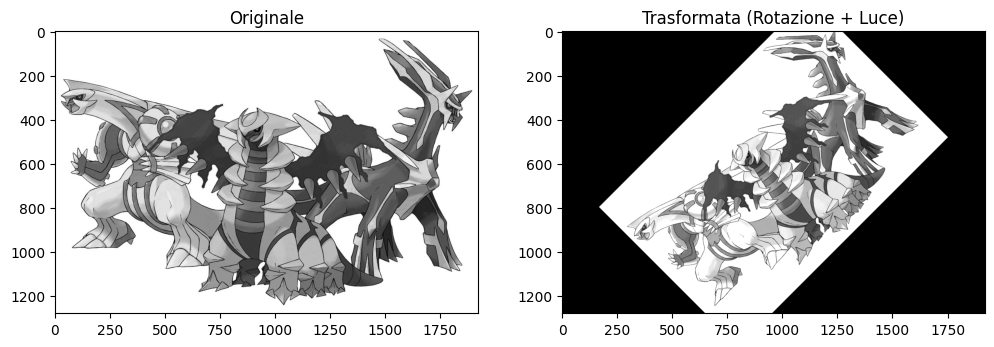

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carichiamo l'immagine
img1 = cv2.imread("../images/mosketeers.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# Creiamo una trasformazione GEOMETRICA (rotazione e scala) e FOTOMETRICA (luminosità)
rows, cols = img1.shape
M = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 0.7) # Ruota 45° e rimpicciolisce
img2 = cv2.warpAffine(img1, M, (cols, rows))
img2 = cv2.add(img2, 50) # Aumentiamo la luminosità di 50 punti

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1, cmap='gray'); ax[0].set_title("Originale")
ax[1].imshow(img2, cmap='gray'); ax[1].set_title("Trasformata (Rotazione + Luce)")
plt.show()

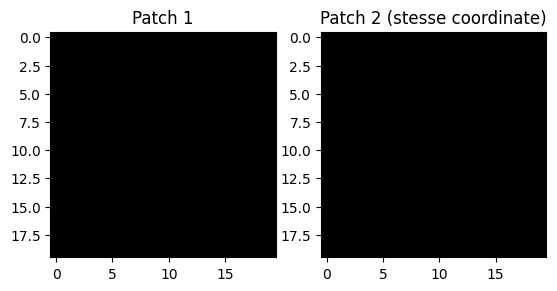

Differenza SSD tra i pixel: 16810000.0


In [2]:
# Estraiamo un quadratino (patch) dallo stesso punto in entrambe le immagini
patch1 = img1[100:120, 100:120]
patch2 = img2[100:120, 100:120]

fig, ax = plt.subplots(1, 2)
ax[0].imshow(patch1, cmap='gray'); ax[0].set_title("Patch 1")
ax[1].imshow(patch2, cmap='gray'); ax[1].set_title("Patch 2 (stesse coordinate)")
plt.show()

# La differenza matematica tra i pixel è enorme anche se il punto è simile!
diff = np.sum((patch1.astype(float) - patch2.astype(float))**2)
print(f"Differenza SSD tra i pixel: {diff}")

In [3]:
# Inizializziamo il rilevatore e descrittore ORB
orb = cv2.ORB_create()

# 1. Trova i keypoints (kp) e calcola i descrittori (des)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# des1 è una matrice dove ogni riga è un VETTORE che descrive un punto
print(f"Forma del descrittore 1: {des1.shape}") 
# Esempio: (500 punti trovati, 32 valori per descrivere ogni punto)

Forma del descrittore 1: (500, 32)


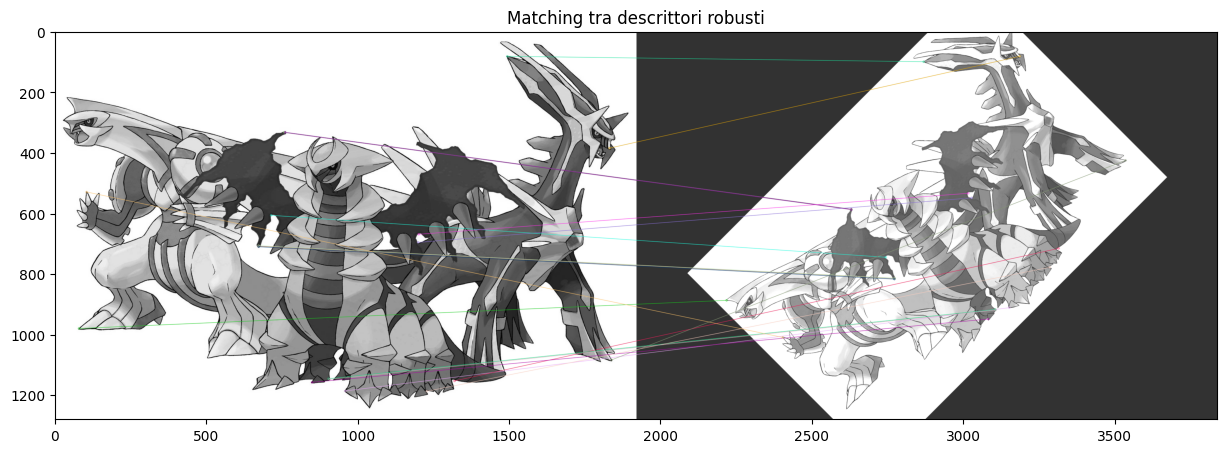

In [4]:
# Usiamo un Matcher a "Forza Bruta" (BFMatcher)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Confronta i descrittori
matches = bf.match(des1, des2)

# Ordiniamoli per distanza (i più simili in cima)
matches = sorted(matches, key = lambda x:x.distance)

# Disegniamo i primi 20 match
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 10))
plt.imshow(img_matches)
plt.title("Matching tra descrittori robusti")
plt.show()

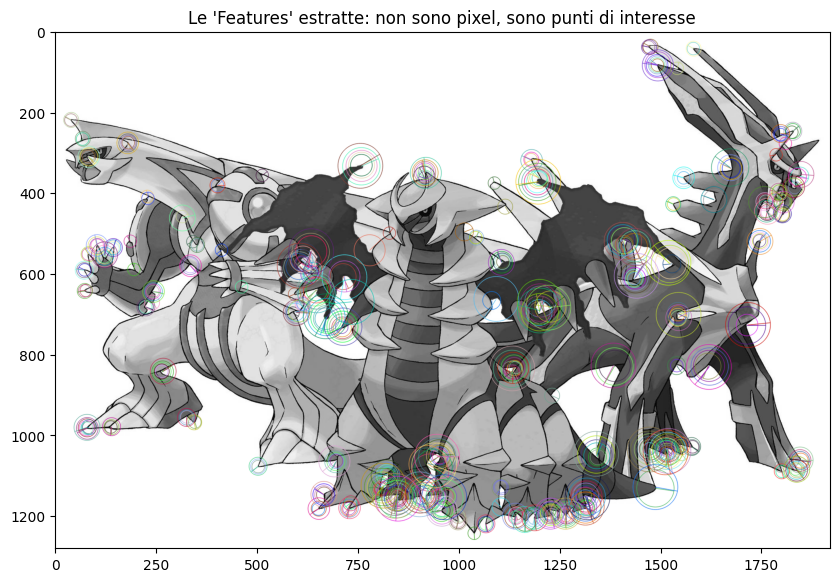

In [5]:
# Disegna i cerchi sopra i punti estratti
img_keypoints = cv2.drawKeypoints(img1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(10, 10))
plt.imshow(img_keypoints)
plt.title("Le 'Features' estratte: non sono pixel, sono punti di interesse")
plt.show()